# iTAPAS チュートリアル: トール (与件) / システム最適 (SO) / Pigovianトール

本ノートブックでは、iTAPAS の拡張機能を体系的に紹介する。

1. **基準UE配分**: トールなし利用者均衡
2. **トールを与件としたUE配分**: リンク別トールを一般化費用に加算
3. **システム最適 (SO) 配分**: マージナルコスト法による求解
4. **Pigovianトール**: SO均衡から得られる一次最適トール
5. **検証**: $f_{UE}^{(\tau^*)} = f_{SO}$ の確認
6. **応用**: カスタムトールパターン (cordon pricing 例)

## 理論的背景

### 利用者均衡 (User Equilibrium, UE) — Wardrop第一原理

全利用者が個人費用最小化行動をとった結果、使用される全経路の費用が等しくなる状態。
リンクコストとして一般化費用 $c_a(f_a) = t_a(f_a) + \tau_a$ を用いる。

$$\min_{f}\ \sum_a \int_0^{f_a} \bigl(t_a(x) + \tau_a\bigr)\,dx \quad \text{s.t.\ flow conservation}$$

### システム最適 (System Optimal, SO) — Wardrop第二原理

総旅行時間 (TSTT) $\sum_a f_a t_a(f_a)$ を最小化する状態。
目的関数の最小化条件はマージナルコスト $\mathrm{mc}_a(f_a) = t_a(f_a) + f_a t'_a(f_a)$ に関するUEと等価:

$$\min_f\ \sum_a f_a t_a(f_a) \iff \text{UE on } \mathrm{mc}_a(f_a)$$

iTAPAS では `alpha_eff = alpha (1+beta)` を渡すだけで BPR 関数形式そのままでマージナルコスト計算が成立する (`mode='SO'`)。

### Pigovian (一次最適) トール

SO 均衡フロー $f^{SO}$ における混雑外部性:

$$\tau^*_a = f^{SO}_a \cdot t'_a(f^{SO}_a)$$

これを与件トールとしてUE配分すると、SOフローを再現する。

## 0. セットアップ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from network import Network
from cost_function import bpr_cost, bpr_cost_derivative, bpr_cost_integral
from itapas import ITAPAS

# Matplotlib スタイル設定 (MatplotlibStyleRule.md 準拠)
COLORS = {
    "red":    "#FF4B00",
    "blue":   "#005AFF",
    "green":  "#03AF7A",
    "cyan":   "#4DC4FF",
    "orange": "#F6AA00",
    "yellow": "#FFF100",
    "purple": "#990099",
    "gray":   "#84919E",
    "black":  "#000000",
}
COLOR_CYCLE = [
    COLORS["red"], COLORS["blue"], COLORS["green"],
    COLORS["cyan"], COLORS["orange"], COLORS["purple"],
    COLORS["gray"], COLORS["black"],
]

mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "IPAexGothic"],
    "font.size":          10,
    "axes.labelsize":     12,
    "axes.titlesize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "mathtext.fontset":   "stixsans",
    "figure.figsize":     (3.5, 2.625),
    "figure.dpi":         150,
    "lines.linewidth":    1.5,
    "lines.markersize":   6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "axes.grid":          False,
    "axes.prop_cycle":    mpl.cycler(color=COLOR_CYCLE),
    "legend.frameon":     False,
})

# 再現性のため乱数シードを固定 (iTAPASのPASシフト順がランダムに依存)
np.random.seed(0)

# Sioux Falls ネットワーク読込
data_dir = "data/SiouxFalls"
net = Network(f"{data_dir}/node.csv", f"{data_dir}/link.csv", f"{data_dir}/demand.csv")
print(f"Sioux Falls: {net.num_nodes}ノード, {net.num_links}リンク, {len(net.demand)} OD対")
print(f"link.csv の vdf_toll 列: 合計 = {net.link_toll.sum():.2f} (デフォルトはゼロ)")

def tstt(flow):
    """Total System Travel Time (実旅行時間ベース)"""
    tt = bpr_cost(flow, net.link_fftt, net.link_capacity, net.link_alpha, net.link_beta)
    return float(np.dot(flow, tt))

solver = ITAPAS(net, bpr_cost, bpr_cost_derivative, bpr_cost_integral)

Sioux Falls: 24ノード, 76リンク, 528 OD対
link.csv の vdf_toll 列: 合計 = 0.00 (デフォルトはゼロ)


## 1. 基準UE配分 (トールなし)

通常の UE: `mode='UE'` (デフォルト), トールはゼロ。

In [2]:
f_ue, log_ue = solver.solve(
    max_iter=80, gap_threshold=1e-6,
    inner_iterations=10, mu=1e-5,
    verbose=False,
)
print(f"UE      :  iters={log_ue[-1]['iter']:3d}, rel_gap={log_ue[-1]['rel_gap']:.2e}, "
      f"TSTT={tstt(f_ue):,.0f}")

UE      :  iters=  8, rel_gap=4.97e-07, TSTT=7,480,158


## 2. 与件トール下のUE配分

リンク別トール $\tau_a$ を `tolls` 引数で渡す。Sioux Falls の主要中央リンクに 一律 $\tau = 5$ を課す例を示す。

実用上は `link.csv` の `vdf_toll` 列にトールパターンを記入しておけば、`Network` が自動読込し `solve()` で省略時に使われる。

In [3]:
# 例: V/C比が高そうな中央部リンクに一律トールを課す (link_id 30~40)
tolls_uniform = np.zeros(net.num_links)
tolls_uniform[30:40] = 5.0

f_ue_t, log_ue_t = solver.solve(
    max_iter=80, gap_threshold=1e-6,
    inner_iterations=10, mu=1e-5,
    tolls=tolls_uniform, verbose=False,
)
print(f"UE+toll :  iters={log_ue_t[-1]['iter']:3d}, rel_gap={log_ue_t[-1]['rel_gap']:.2e}, "
      f"TSTT={tstt(f_ue_t):,.0f}")
print(f"  → トール課金により総旅行時間は {tstt(f_ue_t) - tstt(f_ue):+,.0f} 変化")
print(f"  → トール対象リンクの平均V/C: {(f_ue[30:40] / net.link_capacity[30:40]).mean():.3f} "
      f"→ {(f_ue_t[30:40] / net.link_capacity[30:40]).mean():.3f}")

UE+toll :  iters=  7, rel_gap=9.93e-08, TSTT=7,504,820
  → トール課金により総旅行時間は +24,661 変化
  → トール対象リンクの平均V/C: 1.384 → 1.276


## 3. システム最適 (SO) 配分

`mode='SO'` を指定。マージナルコスト $\mathrm{mc}_a(f_a) = t_a(f_a) + f_a t'_a(f_a)$ を用いた均衡として求解される。

**実装上のメモ**: BPR の場合 $\mathrm{mc}_a(f_a) = t_a^0\bigl(1 + \alpha(1+\beta)(f_a/c_a)^\beta\bigr)$ となるので、`alpha_eff = alpha*(1+beta)` を BPR 関数に渡せば既存実装そのままでマージナルコストが計算できる。

**収束性**: SO ではコスト勾配が UE より急なので、PAS 削除閾値 `mu` は小さめ (例: `1e-7`)、`inner_iterations` は多め (例: `20`) を推奨。

In [4]:
f_so, log_so = solver.solve(
    max_iter=300, gap_threshold=1e-6,
    inner_iterations=20, mu=1e-7,
    mode='SO', verbose=False,
)
print(f"SO      :  iters={log_so[-1]['iter']:3d}, rel_gap={log_so[-1]['rel_gap']:.2e}, "
      f"TSTT={tstt(f_so):,.0f}")
print()
print(f"TSTT 比較:")
print(f"  UE  : {tstt(f_ue):>14,.0f}")
print(f"  SO  : {tstt(f_so):>14,.0f}")
print(f"  改善: {tstt(f_ue) - tstt(f_so):>14,.0f}  ({(tstt(f_ue) - tstt(f_so))/tstt(f_ue)*100:.2f}%)")

SO      :  iters=  5, rel_gap=4.34e-07, TSTT=7,194,256

TSTT 比較:
  UE  :      7,480,158
  SO  :      7,194,256
  改善:        285,902  (3.82%)


## 4. Pigovian (一次最適) トール

`solver.optimal_toll` 属性に、収束フロー $f$ における混雑外部性 $\tau^*_a = f_a \cdot t'_a(f_a)$ が自動格納される。

**注**: 実旅行時間関数 $t$ の導関数を使う (SOモードで内部的に使われる `alpha_eff` ベースのマージナルコスト導関数ではない点に注意)。

In [5]:
tau_star = solver.optimal_toll.copy()  # SO配分後の値
print(f"Pigovianトール τ* = f · t'(f) (リンクあたり)")
print(f"  min    : {tau_star.min():>10.3f}")
print(f"  median : {np.median(tau_star):>10.3f}")
print(f"  mean   : {tau_star.mean():>10.3f}")
print(f"  max    : {tau_star.max():>10.3f}")
print(f"  total  : {tau_star.sum():>10.3f}")

Pigovianトール τ* = f · t'(f) (リンクあたり)
  min    :      0.027
  median :     12.611
  mean   :     16.881
  max    :     58.045
  total  :   1282.993


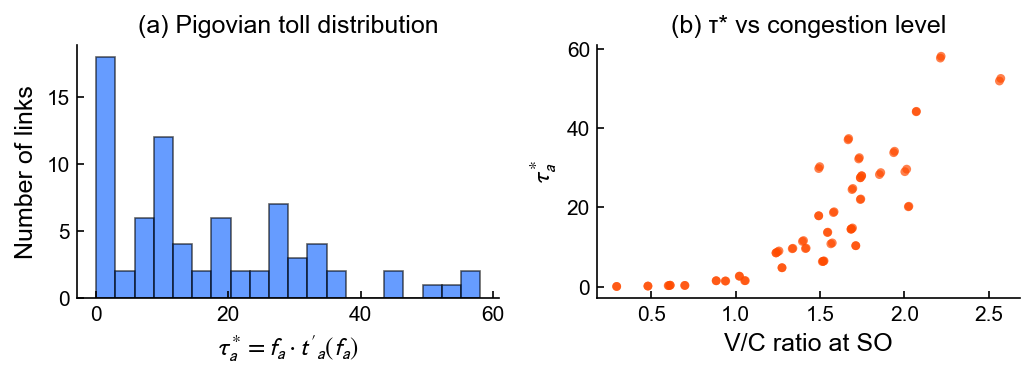

→ 混雑度の高いリンクほどτ*が大きいことが確認できる (BPR の β=4 のため非線形)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625))

# (a) 分布のヒストグラム
ax = axes[0]
ax.hist(tau_star, bins=20, color=COLORS["blue"], alpha=0.6,
        edgecolor=COLORS["black"], linewidth=0.8)
ax.set_xlabel(r"$\tau^*_a = f_a \cdot t'_a(f_a)$")
ax.set_ylabel("Number of links")
ax.set_title("(a) Pigovian toll distribution")

# (b) V/C比 vs τ* (混雑度との関係)
ax = axes[1]
vc_so = f_so / net.link_capacity
ax.scatter(vc_so, tau_star, s=18, alpha=0.7,
           color=COLORS["red"], edgecolors='none')
ax.set_xlabel("V/C ratio at SO")
ax.set_ylabel(r"$\tau^*_a$")
ax.set_title("(b) τ* vs congestion level")

plt.tight_layout()
plt.show()

print("→ 混雑度の高いリンクほどτ*が大きいことが確認できる (BPR の β=4 のため非線形)")

## 5. 検証: $UE^{(\tau^*)} = SO$

Pigovianトール $\tau^*$ を与件としてUE配分すると、理論上SOフローを再現する。
実装の正しさを確認する。

In [7]:
# τ* を与件としてUE配分
f_ue_pigov, log_ue_pigov = solver.solve(
    max_iter=300, gap_threshold=1e-6,
    inner_iterations=20, mu=1e-7,
    mode='UE', tolls=tau_star, verbose=False,
)
print(f"UE+τ*   :  iters={log_ue_pigov[-1]['iter']:3d}, rel_gap={log_ue_pigov[-1]['rel_gap']:.2e}, "
      f"TSTT={tstt(f_ue_pigov):,.0f}")
print()

# フロー一致確認
norm_diff = np.linalg.norm(f_so - f_ue_pigov) / np.linalg.norm(f_so)
norm_diff_ue = np.linalg.norm(f_so - f_ue) / np.linalg.norm(f_so)
print(f"フロー差 ||f_SO - f_UE+τ*|| / ||f_SO|| = {norm_diff:.2e}")
print(f"参考  ||f_SO - f_UE     || / ||f_SO|| = {norm_diff_ue:.2e}  (トールなしUE)")
print()
print(f"→ Pigovianトールにより UE フローは SO に約 {int(norm_diff_ue/norm_diff)} 倍近づいた")

UE+τ*   :  iters=  4, rel_gap=9.49e-09, TSTT=7,194,256

フロー差 ||f_SO - f_UE+τ*|| / ||f_SO|| = 1.08e-05
参考  ||f_SO - f_UE     || / ||f_SO|| = 1.22e-01  (トールなしUE)

→ Pigovianトールにより UE フローは SO に約 11300 倍近づいた


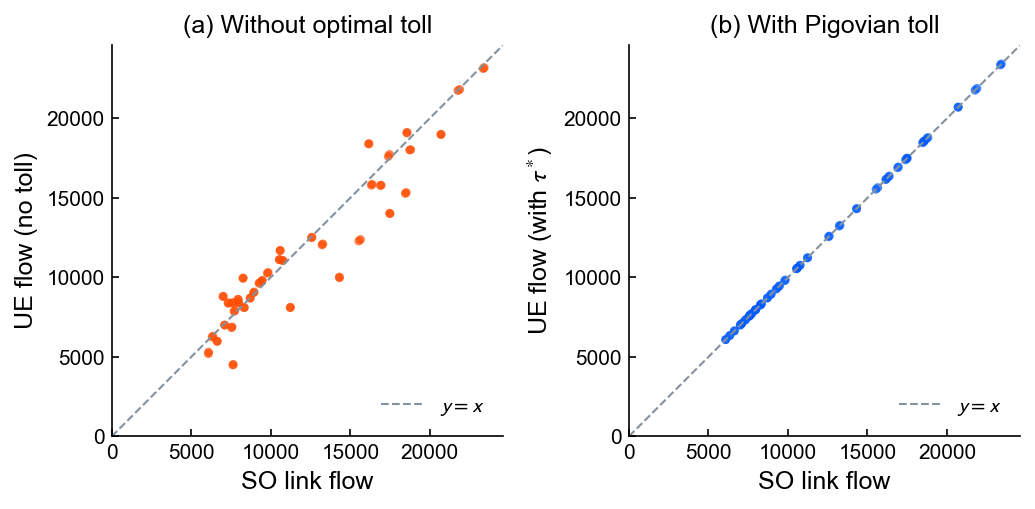

In [8]:
# 散布図: f_SO vs f_UE+τ* (対角線上に乗ればOK)
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5), sharey=False)

lim = max(f_so.max(), f_ue.max(), f_ue_pigov.max()) * 1.05

for ax, ydata, ylabel, color in [
    (axes[0], f_ue,        "UE flow (no toll)", COLORS["red"]),
    (axes[1], f_ue_pigov,  r"UE flow (with $\tau^*$)", COLORS["blue"]),
]:
    ax.scatter(f_so, ydata, s=18, alpha=0.7, color=color, edgecolors='none')
    ax.plot([0, lim], [0, lim], '--', color=COLORS["gray"], linewidth=1.0, label=r"$y=x$")
    ax.set_xlabel("SO link flow")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect('equal')
    ax.legend(loc='lower right')

axes[0].set_title("(a) Without optimal toll")
axes[1].set_title("(b) With Pigovian toll")

plt.tight_layout()
plt.show()

## 6. 応用: cordon pricing 風の任意トールパターン

中心市街地への流入リンクに高トールを課したときの経路変化を観察する。
Sioux Falls ではノード 10 が中心ノードに近いので、ノード 10 への流入リンクに $\tau = 30$ を課す。

In [9]:
# Sioux Falls の zone_id (1-based) は node_id と一致 (ファイル仕様)
# 内部index: node 10 → idx = net.node_id_to_idx[10]
central_node_idx = net.node_id_to_idx[10]

# 中心ノードへの流入リンクを特定
incoming_links = np.where(net.link_to == central_node_idx)[0]
print(f"ノード 10 への流入リンク (内部idx): {incoming_links.tolist()}")

# cordon トール設定
tolls_cordon = np.zeros(net.num_links)
tolls_cordon[incoming_links] = 30.0

# UE配分
f_cordon, log_cordon = solver.solve(
    max_iter=80, gap_threshold=1e-6,
    inner_iterations=10, mu=1e-5,
    mode='UE', tolls=tolls_cordon, verbose=False,
)
print(f"UE+cordon: iters={log_cordon[-1]['iter']:3d}, rel_gap={log_cordon[-1]['rel_gap']:.2e}, "
      f"TSTT={tstt(f_cordon):,.0f}")
print()

# cordon 対象リンクのフロー変化
print("cordon 対象リンクのフロー変化:")
for e in incoming_links:
    f_node = net.idx_to_node_id[net.link_from[e]]
    print(f"  {f_node:2d} → 10 : {f_ue[e]:7.1f} → {f_cordon[e]:7.1f}  ({f_cordon[e] - f_ue[e]:+.1f})")

ノード 10 への流入リンク (内部idx): [24, 31, 42, 47, 50]


UE+cordon: iters=  6, rel_gap=8.03e-07, TSTT=8,556,847

cordon 対象リンクのフロー変化:
   9 → 10 : 21744.4 → 13541.3  (-8203.2)
  11 → 10 : 17604.2 → 11497.1  (-6107.1)
  15 → 10 : 23192.4 → 17788.0  (-5404.4)
  16 → 10 : 11072.9 → 10253.3  (-819.6)
  17 → 10 :  8100.0 →  7449.0  (-651.0)


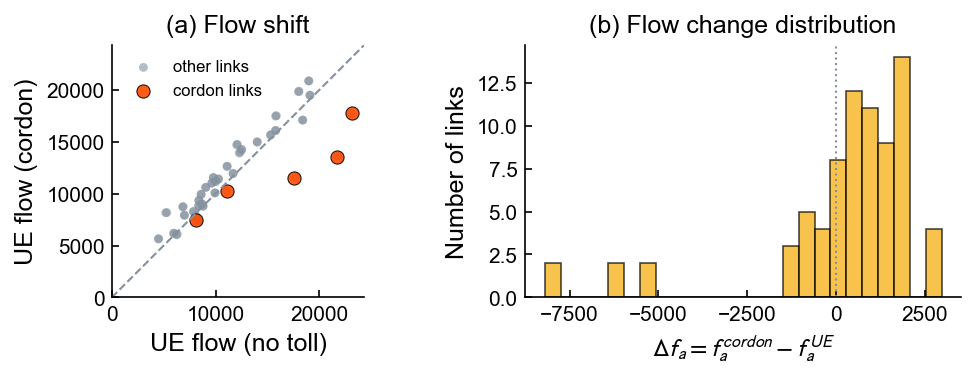

→ 18リンクでフロー減少、56リンクでフロー増加 (迂回経路への分散)


In [10]:
# UE vs UE+cordon のフロー差を可視化
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625))

# (a) リンクフローの散布図
ax = axes[0]
lim = max(f_ue.max(), f_cordon.max()) * 1.05
is_cordon = np.zeros(net.num_links, dtype=bool)
is_cordon[incoming_links] = True
ax.scatter(f_ue[~is_cordon], f_cordon[~is_cordon], s=18, alpha=0.6,
           color=COLORS["gray"], edgecolors='none', label='other links')
ax.scatter(f_ue[is_cordon], f_cordon[is_cordon], s=40, alpha=0.9,
           color=COLORS["red"], edgecolors=COLORS["black"], linewidth=0.5,
           label='cordon links')
ax.plot([0, lim], [0, lim], '--', color=COLORS["gray"], linewidth=1.0)
ax.set_xlabel("UE flow (no toll)")
ax.set_ylabel("UE flow (cordon)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.set_title("(a) Flow shift")

# (b) フロー差の絶対値ヒストグラム
ax = axes[1]
diff = f_cordon - f_ue
ax.hist(diff, bins=25, color=COLORS["orange"], alpha=0.7,
        edgecolor=COLORS["black"], linewidth=0.8)
ax.axvline(x=0, color=COLORS["gray"], linestyle=':', linewidth=1.0)
ax.set_xlabel(r"$\Delta f_a = f^{cordon}_a - f^{UE}_a$")
ax.set_ylabel("Number of links")
ax.set_title("(b) Flow change distribution")

plt.tight_layout()
plt.show()

n_decreased = (diff < -1).sum()
n_increased = (diff > 1).sum()
print(f"→ {n_decreased}リンクでフロー減少、{n_increased}リンクでフロー増加 (迂回経路への分散)")

## 7. まとめ

本ノートブックで紹介した iTAPAS の機能:

| 機能 | 呼び出し例 |
|---|---|
| 標準UE | `solver.solve()` |
| UE + 与件トール | `solver.solve(tolls=tau)` |
| SO (マージナルコスト法) | `solver.solve(mode='SO', mu=1e-7, inner_iterations=20)` |
| SO + 与件トール | `solver.solve(mode='SO', tolls=tau, mu=1e-7)` |
| Pigovianトール取得 | `solver.optimal_toll` (solve後に自動格納) |

**理論的関係:**

$$\text{TSTT}(f^{SO}) \le \text{TSTT}(f^{UE}) \quad,\quad f^{UE^{(\tau^*)}} = f^{SO}$$

**実装メモ:**

- SO では `mu` を UE より小さく (1e-7程度) 設定すると安定して収束。
- iTAPAS の PAS シフト順は `np.random.choice` に依存するため、再現性が必要なら `np.random.seed(...)` を呼出前に設定。
- リンクトールは `link.csv` の `vdf_toll` 列から自動読込もされる (`Network.link_toll`)。